# Start to implement our libaries **bold text**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import zipfile
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline

# Bring our dataset

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tejas14/student-final-grade-prediction-multi-lin-reg")

print("Path to dataset files:", path)

100%|██████████| 7.30k/7.30k [00:00<00:00, 10.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tejas14/student-final-grade-prediction-multi-lin-reg/versions/1


In [13]:
csv_path = os.path.join(path, "student-mat.csv")

students_grades = pd.read_csv(csv_path)
students_grades.head(20)

,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


# Doing EDA

In [14]:
students_grades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   school                    395 non-null    object
 1   sex                       395 non-null    object
 2   age                       395 non-null    int64 
 3   address                   395 non-null    object
 4   famsize                   395 non-null    object
 5   Parrent_status            395 non-null    object
 6   Mother_edu                395 non-null    int64 
 7   Father_edu                395 non-null    int64 
 8   Mother_job                395 non-null    object
 9   Father_job                395 non-null    object
 10  reason_to_chose_school    395 non-null    object
 11  guardian                  395 non-null    object
 12  traveltime                395 non-null    int64 
 13  weekly_studytime          395 non-null    int64 
 14  failures                  

In [15]:
students_grades.describe()

,age,Mother_edu,Father_edu,traveltime,weekly_studytime,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


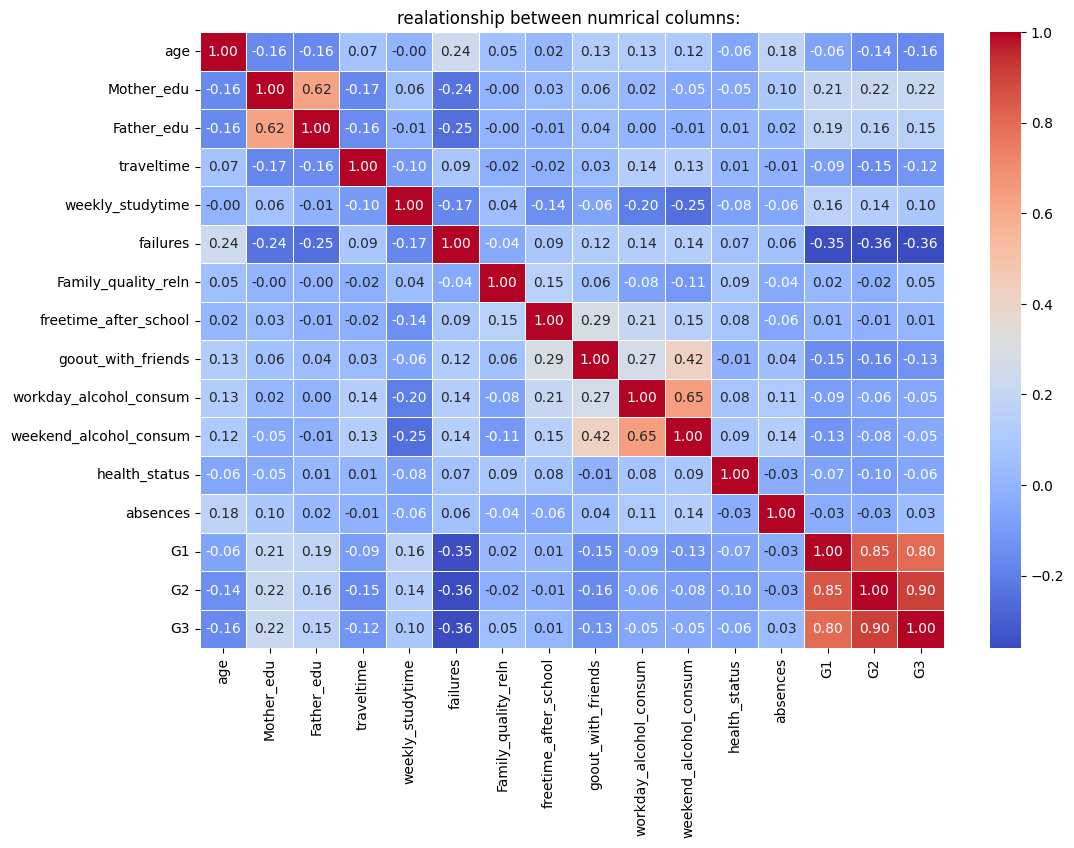

In [24]:
numeric_df = students_grades.select_dtypes(include=['int64', 'float64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,       # To show the numbers inside the squares
            cmap='coolwarm',  # Choose colors that show positive and negative
            fmt=".2f",        # Round numbers to two decimal places
            linewidths=0.5)

plt.title("realationship between numrical columns: ")
plt.show()

In [17]:
missing_values = students_grades.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
school                      0
sex                         0
age                         0
address                     0
famsize                     0
Parrent_status              0
Mother_edu                  0
Father_edu                  0
Mother_job                  0
Father_job                  0
reason_to_chose_school      0
guardian                    0
traveltime                  0
weekly_studytime            0
failures                    0
extra_edu_supp              0
family_edu_supp             0
extra_paid_class            0
extra_curr_activities       0
nursery                     0
Interested_in_higher_edu    0
internet_access             0
romantic_relationship       0
Family_quality_reln         0
freetime_after_school       0
goout_with_friends          0
workday_alcohol_consum      0
weekend_alcohol_consum      0
health_status               0
absences                    0
G1                          0
G2                          0
G3       

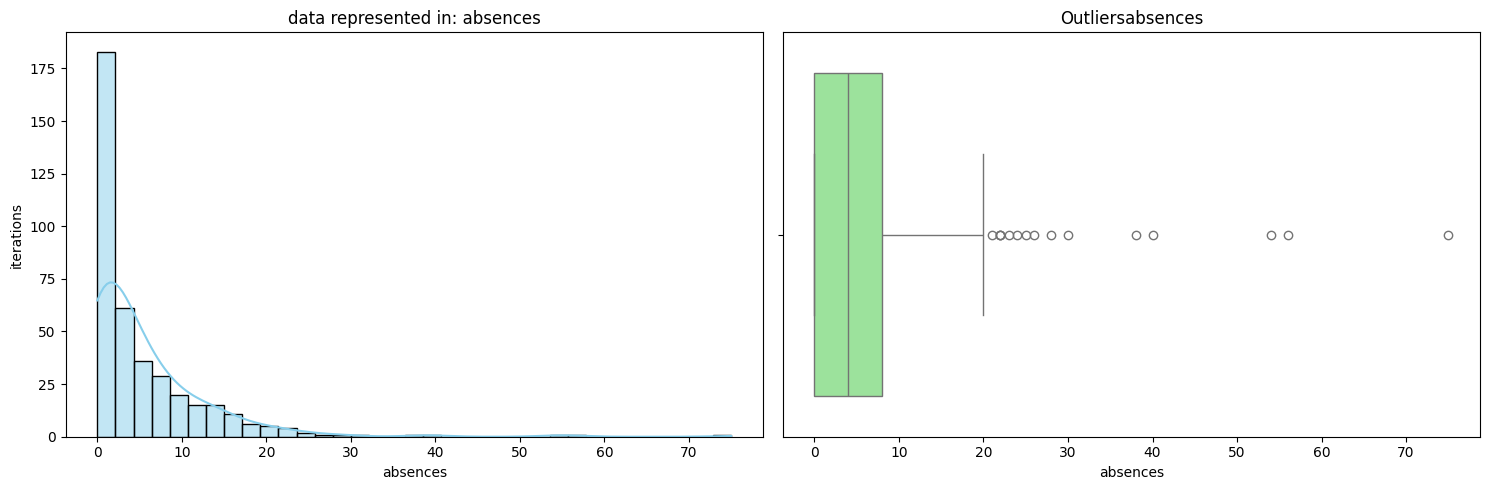

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution_and_outliers(df, column_name):
    # Set up the drawing space (two plots side-by-side)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Plot the distribution (Histogram + KDE)
    sns.histplot(data=df, x=column_name, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'data represented in: {column_name}')
    axes[0].set_ylabel('iterations')

    # 2. Plot the boxplot to detect outliers
    sns.boxplot(data=df, x=column_name, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Outliers{column_name}')

    plt.tight_layout()
    plt.show()

# --- How to use ---
# Select numerical data only (to avoid errors if a text column is passed)
numeric_df = students_grades.select_dtypes(include=['int64', 'float64'])

# You can try it on another column famous for outliers like 'absences'
plot_distribution_and_outliers(numeric_df, 'absences')

# From here we are going through Advanced feature enginnering, first thing we will do is encoding our data and after that doing the scaleing (you can also do feature engineering by creating new columns to get better understanding about you'r data) and after that we will choose one or more than a model to predict our data.

In [19]:
from sklearn.model_selection import train_test_split

X = students_grades.drop('G3', axis=1)
y = students_grades['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Automatically identify text column names (object) and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

# 2. Prepare the Preprocessor to encode text columns only and leave numeric ones as they are
# We use drop='first' to avoid the Dummy Variable Trap, which is very important for Linear Models
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough' # Means let the numeric columns pass through as they are without change
)

# 3. Fit and Transform
# We learn patterns (fit) from training data only, then transform both sets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# 4. (Optional step) Re-transform the output to a DataFrame for easier reading and previewing new names
# Extract new column names after encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_column_names = encoded_cat_cols + numeric_cols

# Convert arrays to DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=all_column_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=all_column_names, index=X_test.index)

print(f"New training data size: {X_train_encoded_df.shape}")
print(f"New test data size: {X_test_encoded_df.shape}")

New training data size: (316, 41)
New test data size: (79, 41)


In [21]:
X_train_encoded_df.head()

,school_MS,sex_M,address_U,famsize_LE3,Parrent_status_T,Mother_job_health,Mother_job_other,Mother_job_services,Mother_job_teacher,Father_job_health,...,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2
181,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,4.0,2.0,3.0,1.0,2.0,3.0,2.0,12.0,13.0
194,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,5.0,3.0,3.0,1.0,1.0,3.0,0.0,13.0,14.0
173,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,3.0,5.0,1.0,1.0,3.0,0.0,8.0,7.0
63,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,3.0,4.0,4.0,2.0,4.0,4.0,2.0,10.0,9.0
253,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,3.0,3.0,2.0,1.0,3.0,3.0,0.0,8.0,9.0


## Scale our data

In [27]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# 1. Calculate the scale and apply it to training data (fit_transform)
X_train_scaled = scaler.fit_transform(X_train_encoded_df)

# 2. Apply the same scale to test data (transform only!)
X_test_scaled = scaler.transform(X_test_encoded_df)

# 3. (Optional but preferred) Return the data to a DataFrame to keep column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded_df.columns, index=X_train_encoded_df.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_encoded_df.columns, index=X_test_encoded_df.index)

# Display the first 5 rows of training data after Scaling to verify
X_train_scaled_df.head()

,school_MS,sex_M,address_U,famsize_LE3,Parrent_status_T,Mother_job_health,Mother_job_other,Mother_job_services,Mother_job_teacher,Father_job_health,...,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2
181,-0.347228,1.079066,0.528538,-0.631055,0.335673,-0.305656,-0.730740,1.661898,-0.402200,-0.230940,...,-0.456744,0.064432,-1.195981,-0.144396,-0.55443,-0.266496,-0.368473,-0.464408,0.332050,0.626163
194,-0.347228,1.079066,0.528538,-0.631055,0.335673,-0.305656,1.368476,-0.601722,-0.402200,-0.230940,...,-0.456744,1.195575,-0.214345,-0.144396,-0.55443,-1.039089,-0.368473,-0.702257,0.643409,0.892831
173,-0.347228,-0.926727,0.528538,-0.631055,0.335673,-0.305656,-0.730740,-0.601722,-0.402200,-0.230940,...,3.628097,0.064432,-0.214345,1.644982,-0.55443,-1.039089,-0.368473,-0.702257,-0.913385,-0.973844
63,-0.347228,-0.926727,0.528538,-0.631055,0.335673,-0.305656,-0.730740,-0.601722,2.486326,4.330127,...,-0.456744,-1.066710,0.767292,0.750293,0.55443,1.278690,0.341512,-0.464408,-0.290667,-0.440508
253,-0.347228,1.079066,-1.892012,-0.631055,0.335673,-0.305656,1.368476,-0.601722,-0.402200,-0.230940,...,-0.456744,-1.066710,-0.214345,-1.039085,-0.55443,0.506097,-0.368473,-0.702257,-0.913385,-0.440508


# *Here* we will use models to finally predict our data and see how our model will work

In [28]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

base_model = Ridge(max_iter=10000)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define a range of values for the model to try and choose the best one
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]}

# 3. Set up the Grid Search tool
# It will train the model with each of the alpha values mentioned above and use KFold to evaluate them
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid, cv=kf, scoring='r2')

# 4. Start training and searching
grid_search.fit(X_train_scaled, y_train)

# Print optimized results
print("-" * 40)
print(f"Best Alpha value found: {grid_search.best_params_['alpha']}")
print(f"Improved average model performance (R-squared): {grid_search.best_score_:.4f}")
print("-" * 40)

----------------------------------------
Best Alpha value found: 10.0
Improved average model performance (R-squared): 0.8066
----------------------------------------


In [29]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Extract the best model from the search tool
best_ridge_model = grid_search.best_estimator_

# 2. Have the model predict grades for the test data (the 20% we isolated)
y_pred_ridge = best_ridge_model.predict(X_test_scaled)

# 3. Calculate final accuracy
test_r2_ridge = r2_score(y_test, y_pred_ridge)
test_mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print("--- Final test results for Ridge model ---")
print(f"Real model accuracy (R-squared): {test_r2_ridge:.4f}")
print(f"Mean Squared Error (MSE): {test_mse_ridge:.4f}")

--- Final test results for Ridge model ---
Real model accuracy (R-squared): 0.7291
Mean Squared Error (MSE): 5.5557


In [30]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Set up the Lasso model and the tool to search for the best Alpha
lasso_model = Lasso(max_iter=10000)
# We tried a smaller range of numbers because Lasso is very sensitive to Alpha
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}

lasso_grid = GridSearchCV(estimator=lasso_model, param_grid=lasso_params, cv=5, scoring='r2')

# 2. Train the model
lasso_grid.fit(X_train_scaled, y_train)

# 3. Final test on the 20%
best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

test_r2_lasso = r2_score(y_test, y_pred_lasso)
test_mse_lasso = mean_squared_error(y_test, y_pred_lasso)

# 4. Print results and comparison
print("-" * 50)
print(f"Best Alpha chosen for Lasso: {lasso_grid.best_params_['alpha']}")
print(f"Real Lasso accuracy (R-squared) on test data: {test_r2_lasso:.4f}")
print(f"Mean Squared Error (MSE): {test_mse_lasso:.4f}")
print("RMSE IS ", np.sqrt(test_mse_lasso))
print("-" * 50)

--------------------------------------------------
Best Alpha chosen for Lasso: 0.1
Real Lasso accuracy (R-squared) on test data: 0.7722
Mean Squared Error (MSE): 4.6715
RMSE IS  2.161367340199006
--------------------------------------------------


In [31]:
import numpy as np

# Calculate absolute differences (errors) between true grade and model prediction
errors = np.abs(y_test - y_pred_lasso)

print("-" * 40)
print(f"Largest error made by the model: {errors.max():.2f} grades")
print(f"Smallest error made by the model: {errors.min():.2f} grades")
print(f"Mean Absolute Error (MAE): {errors.mean():.2f} grades")
print("-" * 40)

----------------------------------------
Largest error made by the model: 8.52 grades
Smallest error made by the model: 0.00 grades
Mean Absolute Error (MAE): 1.38 grades
----------------------------------------


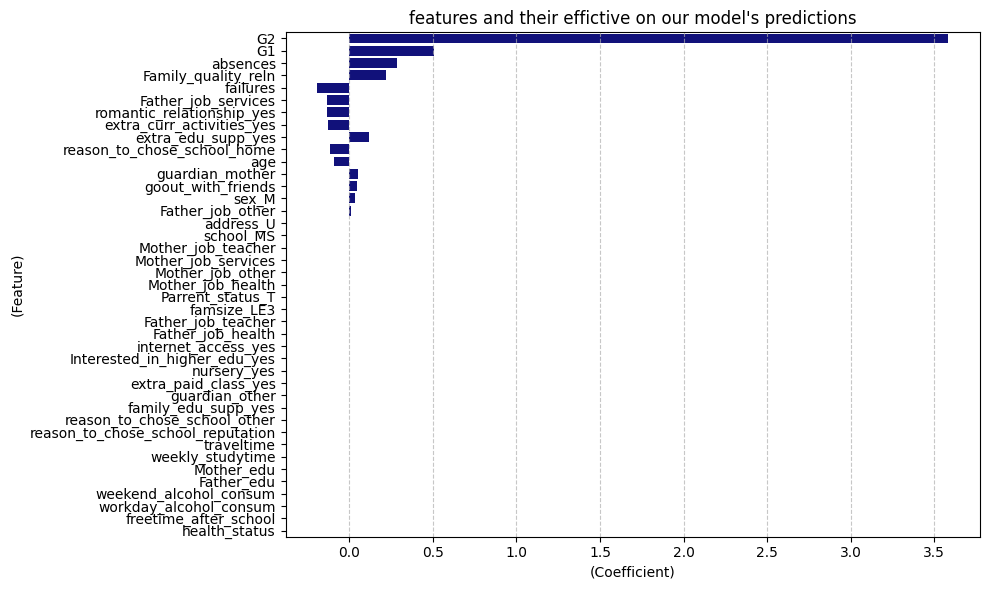

                              Feature  Coefficient
40                                 G2     3.584742
39                                 G1     0.504480
38                           absences     0.285289
32                Family_quality_reln     0.221720
31                           failures    -0.192872
11                Father_job_services    -0.133578
25          romantic_relationship_yes    -0.132506
21          extra_curr_activities_yes    -0.130070
18                 extra_edu_supp_yes     0.115071
13        reason_to_chose_school_home    -0.113460
26                                age    -0.091345
16                    guardian_mother     0.049485
34                 goout_with_friends     0.045730
1                               sex_M     0.034313
10                   Father_job_other     0.009251
2                           address_U     0.000000
0                           school_MS    -0.000000
8                  Mother_job_teacher     0.000000
7                 Mother_job_se

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract model coefficients (weights) and link them to column names
# We used X_train_encoded_df.columns because it contains feature names in the same order
coefficients = pd.DataFrame({
    'Feature': X_train_encoded_df.columns,
    'Coefficient': best_lasso.coef_
})

# 2. Sort columns by impact (from strongest impact to weakest)
# We use the absolute value (abs) to sort the strength of impact regardless of whether it raises or lowers the value
coefficients['Absolute_Importance'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute_Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
# We plot the original values (Coefficient) to see what raises the score (positive) and what lowers it (negative)
sns.barplot(x='Coefficient', y='Feature', data=coefficients, color="darkblue")
plt.title("features and their effictive on our model's predictions")
plt.xlabel('(Coefficient)')
plt.ylabel('(Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the table as numbers too
print(coefficients[['Feature', 'Coefficient']])

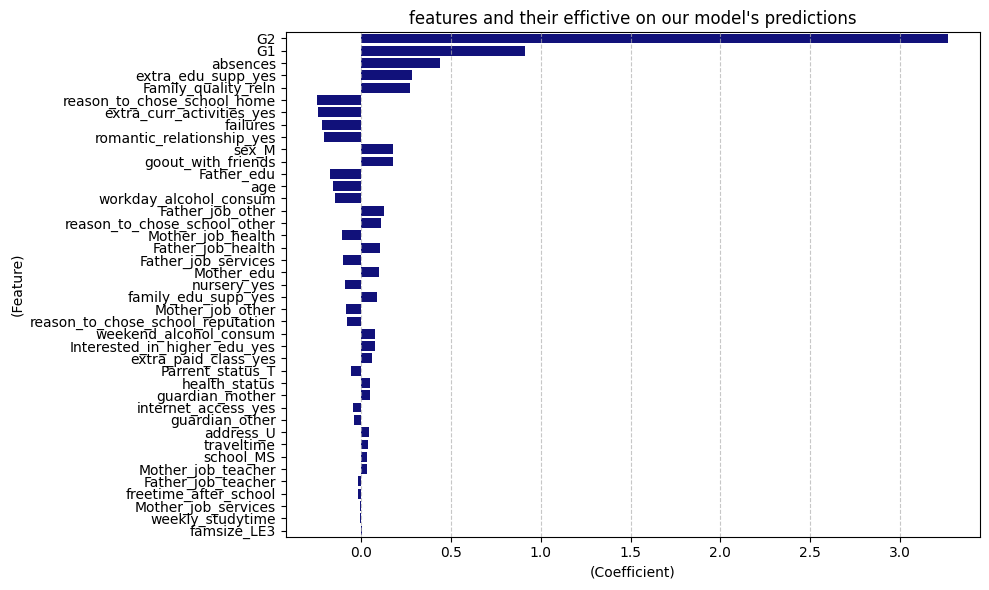

                              Feature  Coefficient
40                                 G2     3.270226
39                                 G1     0.909280
38                           absences     0.440640
18                 extra_edu_supp_yes     0.279603
32                Family_quality_reln     0.269849
13        reason_to_chose_school_home    -0.246677
21          extra_curr_activities_yes    -0.241898
31                           failures    -0.218390
25          romantic_relationship_yes    -0.205662
1                               sex_M     0.178574
34                 goout_with_friends     0.177117
28                         Father_edu    -0.173152
26                                age    -0.159617
35             workday_alcohol_consum    -0.147933
10                   Father_job_other     0.126668
14       reason_to_chose_school_other     0.109355
5                   Mother_job_health    -0.108595
9                   Father_job_health     0.104227
11                Father_job_se

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract model coefficients (weights) and link them to column names
# We used X_train_encoded_df.columns because it contains feature names in the same order
coefficients = pd.DataFrame({
    'Feature':  X_train_encoded_df.columns,
    'Coefficient': best_ridge_model.coef_
})

# 2. Sort columns by impact (from strongest impact to weakest)
# We use the absolute value (abs) to sort the strength of impact regardless of whether it raises or lowers the value
coefficients['Absolute_Importance'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute_Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
# We plot the original values (Coefficient) to see what raises the score (positive) and what lowers it (negative)
sns.barplot(x='Coefficient', y='Feature', data=coefficients, color="darkblue")
plt.title("features and their effictive on our model's predictions")
plt.xlabel('(Coefficient)')
plt.ylabel('(Feature)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the table as numbers too
print(coefficients[['Feature', 'Coefficient']])